 Estimation de la Taille du Secteur Informel par Région
  Modèle de Prédiction par Régression
=========================================================
Préparé par   : Wiam Fahim /Meryem FAKLANI

Sujet    : Machine Learning en Finance


  ANALYSE EXPLORATOIRE DU JEU DE DONNÉES

Dimensions : 120 observations × 11 variables

── Aperçu des données ──
           region  annee  pib_regional  taux_chomage  taux_pauvrete  alphabetisation  densite_pop  part_agri  acces_finance  taux_urbanisation  taille_informel
Casablanca-Settat   2014        114.83         16.38           7.21            56.24       241.75      30.72          53.06              77.48            24.36
Casablanca-Settat   2015        117.75         10.57          11.21            70.99      1733.46      12.32          53.65              43.37            21.63
Casablanca-Settat   2016        121.53         13.13          15.31            81.41       806.70      19.46          52.58              37.79            20.93
Casablanca-Settat   2017        122.55         21.28          29.07            82.34      1225.41       6.13          57.63              61.41            22.85
Casablanca-Settat   2018        126.08         14.93           3.93            86.37   

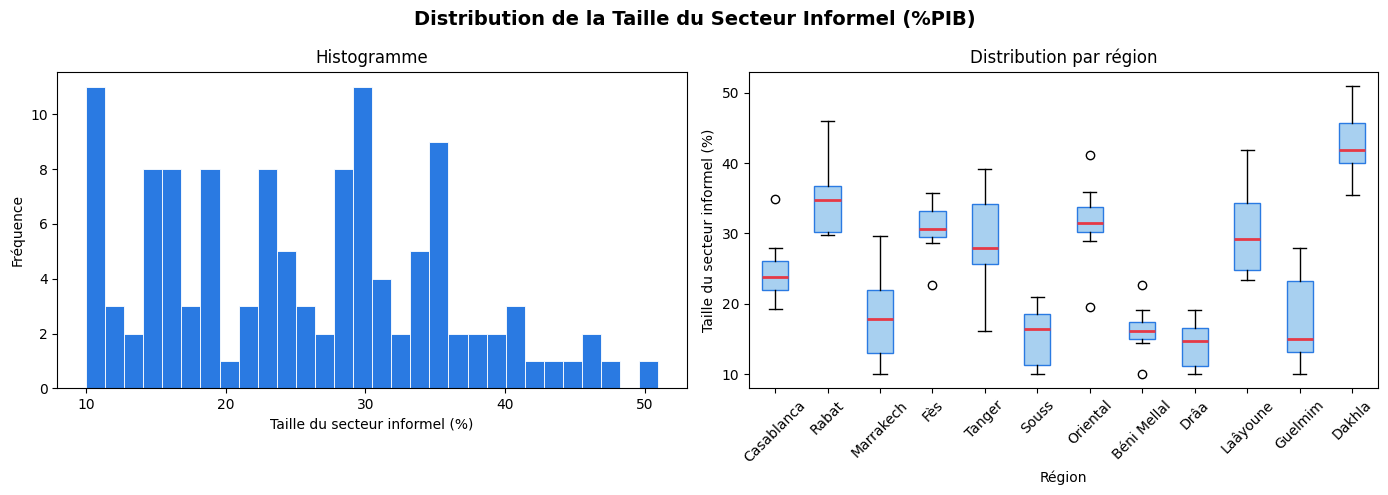

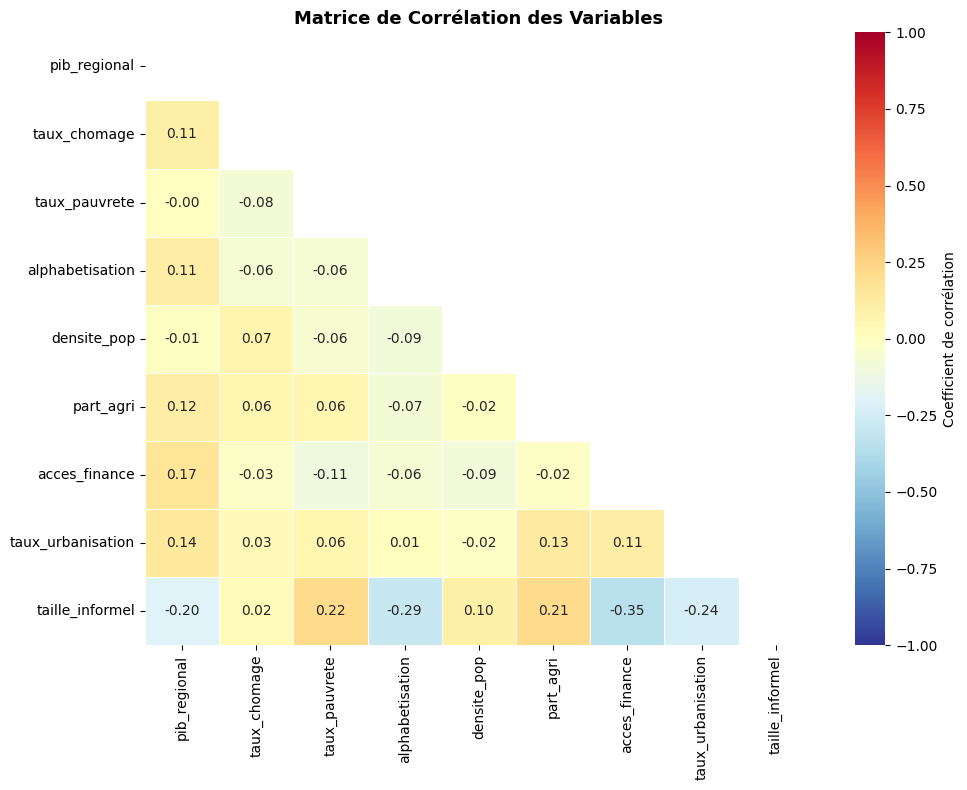

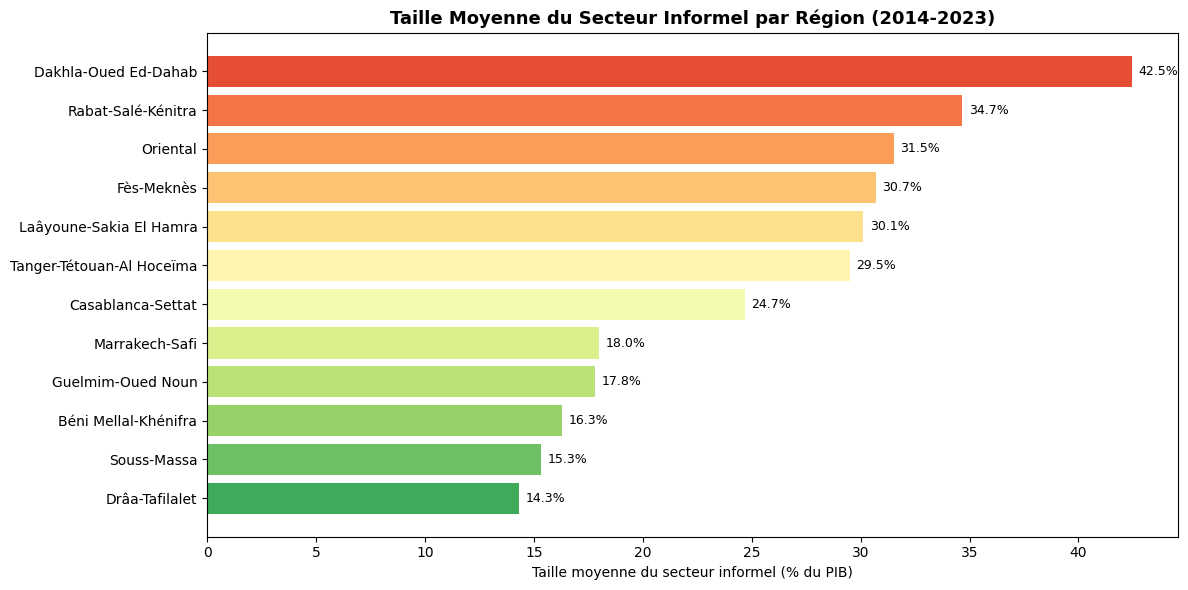


Taille Train : 96 | Taille Test : 24

  RÉSULTATS DES MODÈLES DE RÉGRESSION
Modèle                           RMSE      MAE       R²      CV R²
------------------------------------------------------------------
Régression Linéaire             2.244    1.781   0.9364     0.9197
Ridge (α=1.0)                   2.478    1.931   0.9224     0.9195
Lasso (α=0.5)                   3.895    3.162   0.8084     0.8450
Random Forest                   6.828    5.738   0.4110     0.5430
Gradient Boosting               4.953    3.923   0.6901     0.5674
------------------------------------------------------------------

✔ Meilleur modèle : Régression Linéaire  (R² test = 0.9364)


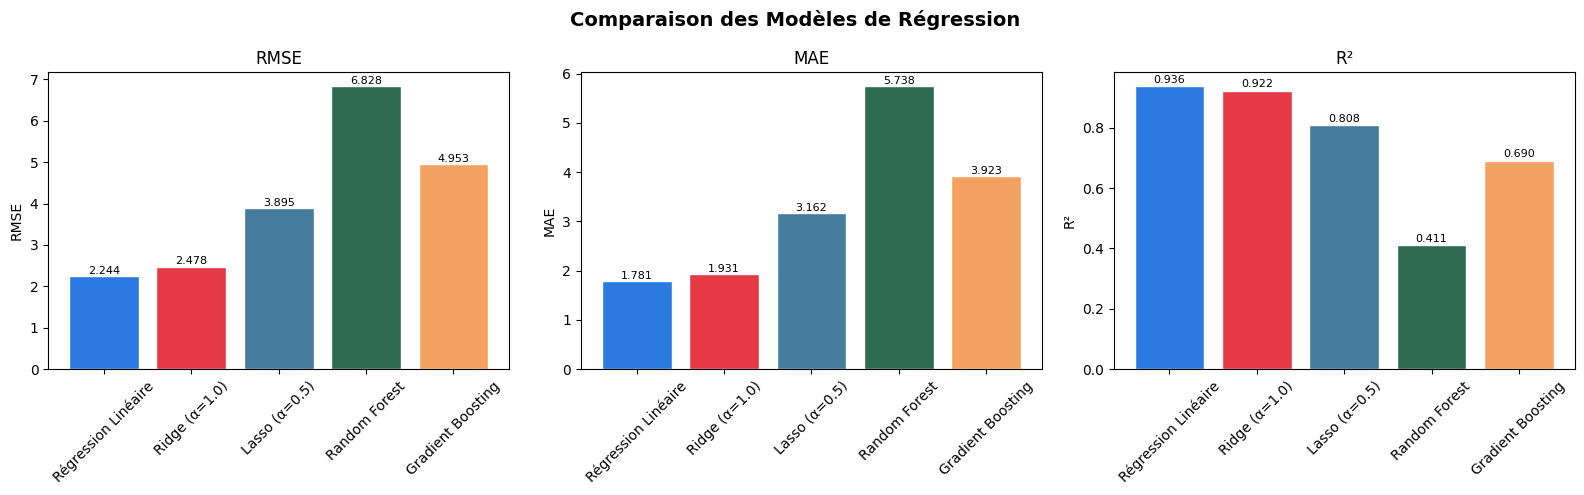

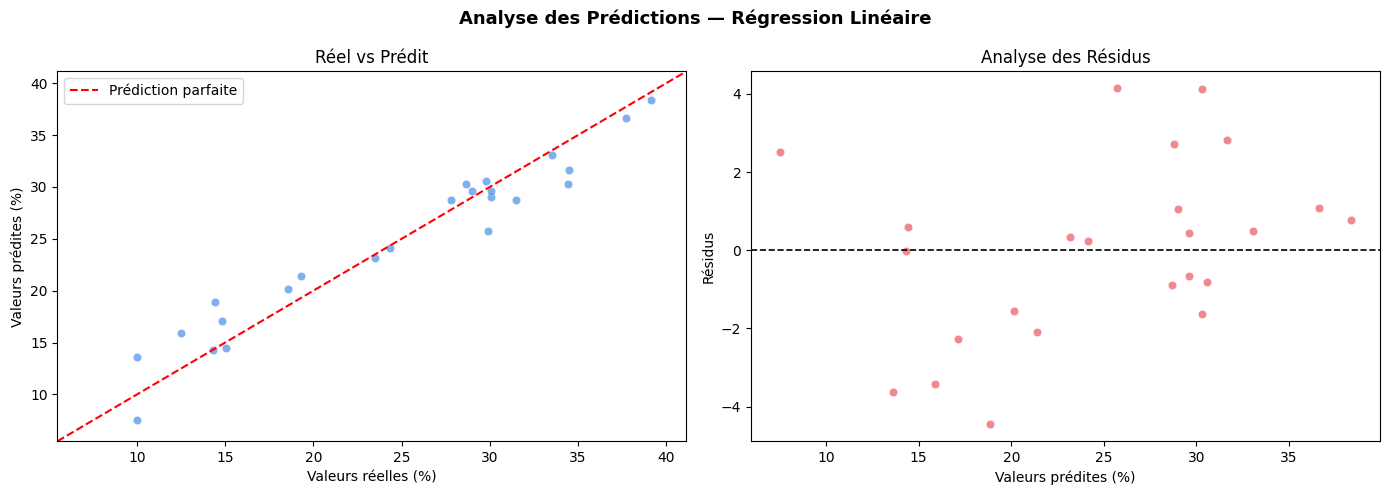

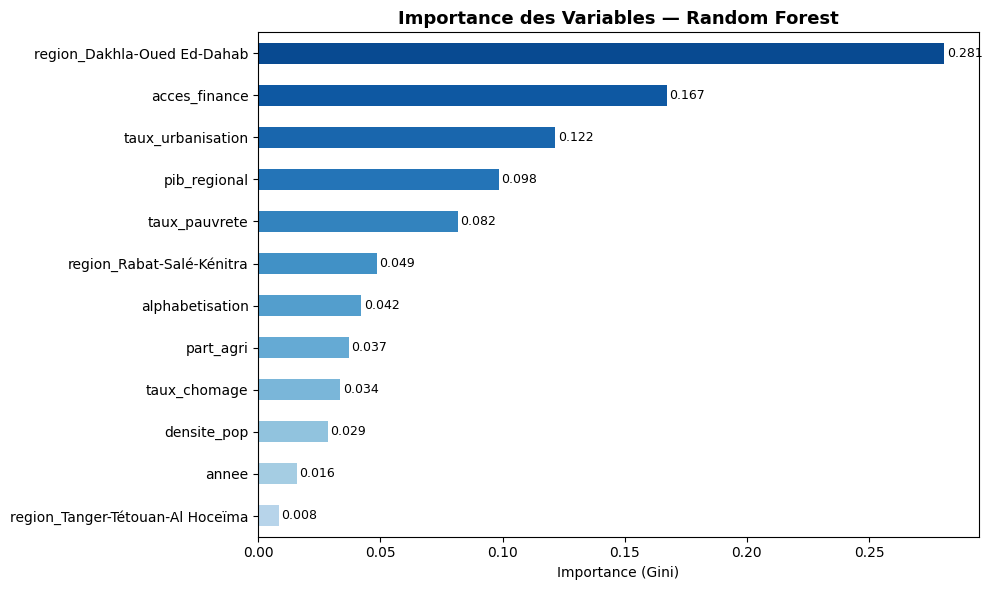


  PRÉDICTIONS 2024-2028 PAR RÉGION

Taille estimée du secteur informel (% du PIB) :
annee                       2024   2025   2026   2027   2028
region                                                      
Béni Mellal-Khénifra       17.78  17.78  17.78  17.78  17.78
Casablanca-Settat          17.15  17.10  17.05  17.00  16.95
Dakhla-Oued Ed-Dahab       17.65  17.63  17.60  17.57  17.54
Drâa-Tafilalet              7.19   7.16   7.13   7.10   7.07
Fès-Meknès                 22.13  22.16  22.19  22.21  22.24
Guelmim-Oued Noun          11.32  11.29  11.26  11.22  11.18
Laâyoune-Sakia El Hamra    15.89  15.89  15.88  15.88  15.87
Marrakech-Safi             18.95  18.91  18.86  18.81  18.76
Oriental                   10.10  10.11  10.12  10.13  10.14
Rabat-Salé-Kénitra         18.62  18.61  18.60  18.58  18.56
Souss-Massa                20.81  20.80  20.79  20.77  20.76
Tanger-Tétouan-Al Hoceïma  12.77  12.74  12.71  12.68  12.64


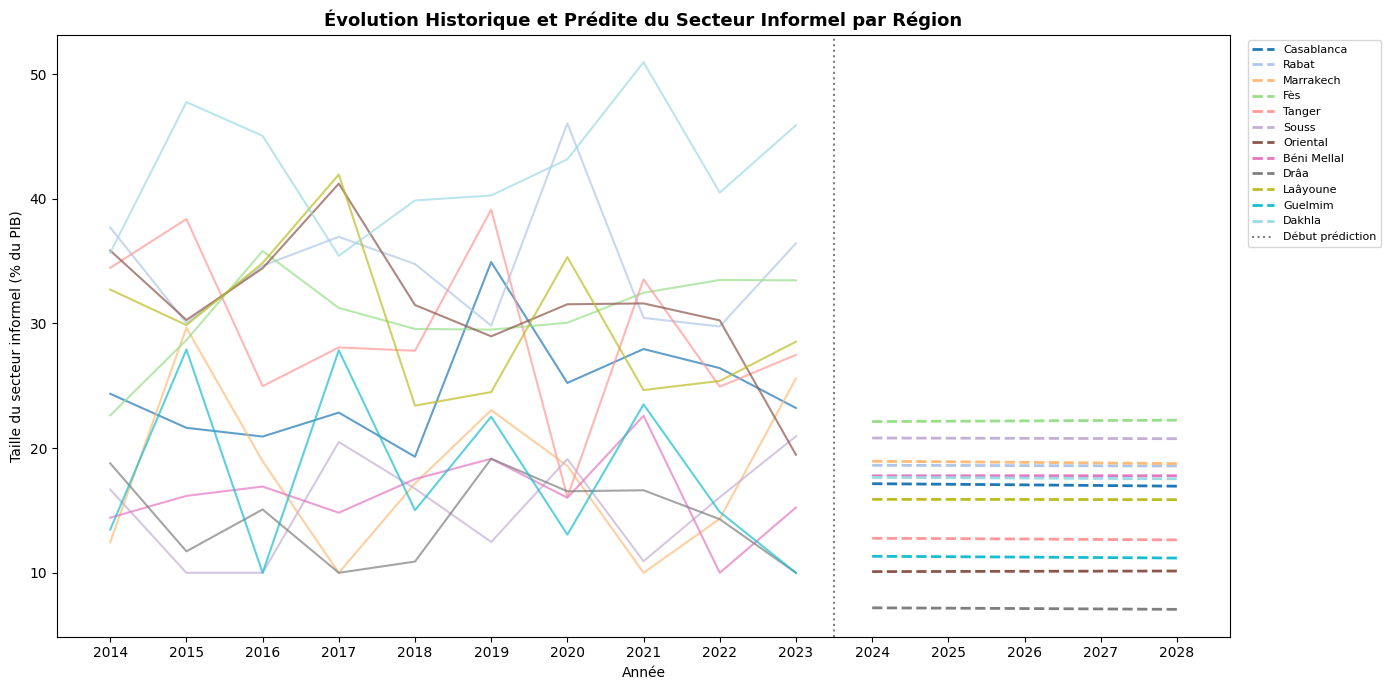


  RAPPORT SYNTHÉTIQUE

  Meilleur modèle    : Régression Linéaire
  R² (test)          : 0.9364
  RMSE               : 2.244 points de %
  MAE                : 1.781 points de %

  Région avec secteur informel le + élevé (moy.) :
    → Dakhla-Oued Ed-Dahab (42.5%)

  Région avec secteur informel le + faible (moy.) :
    → Drâa-Tafilalet (14.3%)

  Top 3 variables explicatives :
    • region_Dakhla-Oued Ed-Dahab
    • acces_finance
    • taux_urbanisation

  Fichiers sauvegardés : fig1 à fig7 + secteur_informel_regression.py


In [2]:


# ─────────────────────────────────────────────
#  1. IMPORTATION DES BIBLIOTHÈQUES
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────────
#  2. GÉNÉRATION DU JEU DE DONNÉES SYNTHÉTIQUE
#     (représentatif du Maroc : 12 régions)
# ─────────────────────────────────────────────
np.random.seed(42)

REGIONS = [
    "Casablanca-Settat", "Rabat-Salé-Kénitra", "Marrakech-Safi",
    "Fès-Meknès", "Tanger-Tétouan-Al Hoceïma", "Souss-Massa",
    "Oriental", "Béni Mellal-Khénifra", "Drâa-Tafilalet",
    "Laâyoune-Sakia El Hamra", "Guelmim-Oued Noun", "Dakhla-Oued Ed-Dahab"
]

N_YEARS  = 10          # 2014-2023
N_REGIONS = len(REGIONS)
N_TOTAL   = N_REGIONS * N_YEARS

# Construction du DataFrame
records = []
for i, region in enumerate(REGIONS):
    # Paramètres de base propres à chaque région
    base_informal = np.random.uniform(25, 55)   # % du PIB informel
    gdp_base      = np.random.uniform(15, 120)  # PIB en milliards MAD
    for year in range(2014, 2024):
        t = year - 2014
        gdp             = gdp_base * (1 + np.random.uniform(0.02, 0.05)) ** t
        taux_chomage    = np.random.uniform(8, 22)
        taux_pauvrete   = np.random.uniform(3, 30)
        alphabetisation = np.random.uniform(50, 90)
        densite_pop     = np.random.uniform(10, 4000)
        part_agri       = np.random.uniform(3, 35)
        acces_finance   = np.random.uniform(20, 75)
        taux_urbanisation = np.random.uniform(35, 95)

        # Variable cible : taille du secteur informel (% du PIB régional)
        informal_size = (
            base_informal
            + 0.35 * taux_chomage
            + 0.20 * taux_pauvrete
            - 0.15 * alphabetisation
            - 0.01 * np.log1p(densite_pop)
            + 0.25 * part_agri
            - 0.18 * acces_finance
            - 0.10 * taux_urbanisation
            + np.random.normal(0, 2)   # bruit résiduel
        )
        informal_size = np.clip(informal_size, 10, 70)

        records.append({
            "region":            region,
            "annee":             year,
            "pib_regional":      round(gdp, 2),
            "taux_chomage":      round(taux_chomage, 2),
            "taux_pauvrete":     round(taux_pauvrete, 2),
            "alphabetisation":   round(alphabetisation, 2),
            "densite_pop":       round(densite_pop, 2),
            "part_agri":         round(part_agri, 2),
            "acces_finance":     round(acces_finance, 2),
            "taux_urbanisation": round(taux_urbanisation, 2),
            "taille_informel":   round(informal_size, 2)   # TARGET
        })

df = pd.DataFrame(records)

# ─────────────────────────────────────────────
#  3. ANALYSE EXPLORATOIRE (EDA)
# ─────────────────────────────────────────────
print("=" * 60)
print("  ANALYSE EXPLORATOIRE DU JEU DE DONNÉES")
print("=" * 60)
print(f"\nDimensions : {df.shape[0]} observations × {df.shape[1]} variables")
print("\n── Aperçu des données ──")
print(df.head(10).to_string(index=False))
print("\n── Statistiques descriptives ──")
print(df.describe().round(2).to_string())
print("\n── Valeurs manquantes ──")
print(df.isnull().sum())

# ── Figure 1 : Distribution de la variable cible ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la Taille du Secteur Informel (%PIB)", fontsize=14, fontweight="bold")

axes[0].hist(df["taille_informel"], bins=30, color="#2a7ae2", edgecolor="white", linewidth=0.6)
axes[0].set_xlabel("Taille du secteur informel (%)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme")

axes[1].boxplot([df[df["region"] == r]["taille_informel"].values for r in REGIONS],
                labels=[r.split("-")[0] for r in REGIONS],
                patch_artist=True,
                boxprops=dict(facecolor="#a8d0f0", color="#2a7ae2"),
                medianprops=dict(color="#e63946", linewidth=2))
axes[1].set_xlabel("Région")
axes[1].set_ylabel("Taille du secteur informel (%)")
axes[1].set_title("Distribution par région")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fig1_distribution_cible.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2 : Matrice de corrélation ──────────────
numeric_cols = ["pib_regional", "taux_chomage", "taux_pauvrete",
                "alphabetisation", "densite_pop", "part_agri",
                "acces_finance", "taux_urbanisation", "taille_informel"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"label": "Coefficient de corrélation"})
ax.set_title("Matrice de Corrélation des Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3 : Taille informel moyenne par région ──────────────
region_stats = df.groupby("region")["taille_informel"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(region_stats.index, region_stats.values,
               color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(region_stats))))
ax.set_xlabel("Taille moyenne du secteur informel (% du PIB)")
ax.set_title("Taille Moyenne du Secteur Informel par Région (2014-2023)",
             fontsize=13, fontweight="bold")
for bar, val in zip(bars, region_stats.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_secteur_par_region.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
#  4. PRÉPARATION DES DONNÉES
# ─────────────────────────────────────────────
FEATURES = ["pib_regional", "taux_chomage", "taux_pauvrete",
            "alphabetisation", "densite_pop", "part_agri",
            "acces_finance", "taux_urbanisation", "annee"]
TARGET = "taille_informel"

X = df[FEATURES]
y = df[TARGET]

# Encodage one-hot de la région (effet fixe régional)
region_dummies = pd.get_dummies(df["region"], prefix="region", drop_first=True)
X = pd.concat([X.reset_index(drop=True), region_dummies.reset_index(drop=True)], axis=1)

# Split train/test (80/20) — stratification temporelle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTaille Train : {X_train.shape[0]} | Taille Test : {X_test.shape[0]}")

# ─────────────────────────────────────────────
#  5. DÉFINITION ET ENTRAÎNEMENT DES MODÈLES
# ─────────────────────────────────────────────
models = {
    "Régression Linéaire":   LinearRegression(),
    "Ridge (α=1.0)":         Ridge(alpha=1.0),
    "Lasso (α=0.5)":         Lasso(alpha=0.5, max_iter=5000),
    "Random Forest":         RandomForestRegressor(n_estimators=200, max_depth=8,
                                                    random_state=42, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print("\n" + "=" * 60)
print("  RÉSULTATS DES MODÈLES DE RÉGRESSION")
print("=" * 60)
print(f"{'Modèle':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'CV R²':>10}")
print("-" * 66)

for name, model in models.items():
    # Utilisation des données normalisées pour les modèles linéaires
    if name in ["Régression Linéaire", "Ridge (α=1.0)", "Lasso (α=0.5)"]:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train.values, X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(model, Xtr, y_train, cv=kf, scoring="r2").mean()

    results[name] = {"model": model, "y_pred": y_pred,
                     "RMSE": rmse, "MAE": mae, "R2": r2, "CV_R2": cv_r2}
    print(f"{name:<28} {rmse:>8.3f} {mae:>8.3f} {r2:>8.4f} {cv_r2:>10.4f}")

print("-" * 66)

# Meilleur modèle selon R²
best_name = max(results, key=lambda k: results[k]["R2"])
best      = results[best_name]
print(f"\n✔ Meilleur modèle : {best_name}  (R² test = {best['R2']:.4f})")

# ─────────────────────────────────────────────
#  6. VISUALISATIONS DES PERFORMANCES
# ─────────────────────────────────────────────

# ── Figure 4 : Comparaison des métriques ──────────────
metrics_df = pd.DataFrame({
    "Modèle": list(results.keys()),
    "RMSE":   [v["RMSE"]   for v in results.values()],
    "MAE":    [v["MAE"]    for v in results.values()],
    "R²":     [v["R2"]     for v in results.values()],
    "CV R²":  [v["CV_R2"]  for v in results.values()],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des Modèles de Régression", fontsize=14, fontweight="bold")

colors = ["#2a7ae2", "#e63946", "#457b9d", "#2d6a4f", "#f4a261"]
for ax, metric in zip(axes, ["RMSE", "MAE", "R²"]):
    bars = ax.bar(metrics_df["Modèle"], metrics_df[metric], color=colors, edgecolor="white")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig4_comparaison_modeles.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 5 : Valeurs réelles vs prédites (meilleur modèle) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Analyse des Prédictions — {best_name}", fontsize=13, fontweight="bold")

y_pred_best = best["y_pred"]
lim = (min(y_test.min(), y_pred_best.min()) - 2,
       max(y_test.max(), y_pred_best.max()) + 2)

axes[0].scatter(y_test, y_pred_best, alpha=0.6, color="#2a7ae2", edgecolors="white", linewidth=0.4)
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Prédiction parfaite")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("Valeurs réelles (%)")
axes[0].set_ylabel("Valeurs prédites (%)")
axes[0].set_title("Réel vs Prédit")
axes[0].legend()

residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color="#e63946", edgecolors="white", linewidth=0.4)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Valeurs prédites (%)")
axes[1].set_ylabel("Résidus")
axes[1].set_title("Analyse des Résidus")

plt.tight_layout()
plt.savefig("fig5_prediction_residus.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 6 : Importance des variables (Random Forest) ──────
rf_model = results["Random Forest"]["model"]
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)

# Garder les 12 plus importantes
feat_imp_top = feat_imp.tail(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp_top)))
feat_imp_top.plot(kind="barh", color=colors_imp, ax=ax)
ax.set_title("Importance des Variables — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (Gini)")
for i, v in enumerate(feat_imp_top.values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig6_importance_variables.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 7 : Évolution prédite par région (2024-2028) ──────
print("\n" + "=" * 60)
print("  PRÉDICTIONS 2024-2028 PAR RÉGION")
print("=" * 60)

# Construire un jeu de données futur
future_records = []
for region in REGIONS:
    historical = df[df["region"] == region].iloc[-1]   # dernière année disponible
    for year in range(2024, 2029):
        row = historical.copy()
        row["annee"] = year
        row["pib_regional"] *= (1.035 ** (year - 2023))
        row["taux_chomage"]  = max(5, row["taux_chomage"] - 0.3)
        row["acces_finance"] = min(90, row["acces_finance"] + 0.5)
        future_records.append(row)

df_future = pd.DataFrame(future_records)

X_future = df_future[FEATURES]
region_dummies_future = pd.get_dummies(df_future["region"], prefix="region")
# Aligner les colonnes
for col in X.columns:
    if col not in X_future.columns and col not in FEATURES:
        X_future[col] = 0
X_future = X_future.reindex(columns=X.columns, fill_value=0)

# Prédiction avec le meilleur modèle
if best_name in ["Régression Linéaire", "Ridge (α=1.0)", "Lasso (α=0.5)"]:
    X_future_input = scaler.transform(X_future)
else:
    X_future_input = X_future.values

df_future["prediction"] = best["model"].predict(X_future_input)

# Affichage du tableau de prédictions
pivot_pred = df_future.pivot_table(
    index="region", columns="annee", values="prediction"
).round(2)

print("\nTaille estimée du secteur informel (% du PIB) :")
print(pivot_pred.to_string())

# Graphique évolution future
fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.tab20(np.linspace(0, 1, N_REGIONS))
for i, region in enumerate(REGIONS):
    # Historique
    hist = df[df["region"] == region].groupby("annee")["taille_informel"].mean()
    ax.plot(hist.index, hist.values, color=cmap[i], linewidth=1.5, alpha=0.7)
    # Prédictions futures
    fut = df_future[df_future["region"] == region].groupby("annee")["prediction"].mean()
    ax.plot(fut.index, fut.values, color=cmap[i], linewidth=2, linestyle="--",
            label=region.split("-")[0])

ax.axvline(2023.5, color="gray", linestyle=":", linewidth=1.5, label="Début prédiction")
ax.set_xlabel("Année")
ax.set_ylabel("Taille du secteur informel (% du PIB)")
ax.set_title("Évolution Historique et Prédite du Secteur Informel par Région",
             fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, ncol=1)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("fig7_evolution_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
#  7. RAPPORT SYNTHÉTIQUE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  RAPPORT SYNTHÉTIQUE")
print("=" * 60)
print(f"\n  Meilleur modèle    : {best_name}")
print(f"  R² (test)          : {best['R2']:.4f}")
print(f"  RMSE               : {best['RMSE']:.3f} points de %")
print(f"  MAE                : {best['MAE']:.3f} points de %")
print(f"\n  Région avec secteur informel le + élevé (moy.) :")
top_region = df.groupby("region")["taille_informel"].mean().idxmax()
print(f"    → {top_region} ({df.groupby('region')['taille_informel'].mean()[top_region]:.1f}%)")
print(f"\n  Région avec secteur informel le + faible (moy.) :")
low_region = df.groupby("region")["taille_informel"].mean().idxmin()
print(f"    → {low_region} ({df.groupby('region')['taille_informel'].mean()[low_region]:.1f}%)")
print(f"\n  Top 3 variables explicatives :")
for feat in feat_imp.tail(3).index[::-1]:
    print(f"    • {feat}")
print("\n  Fichiers sauvegardés : fig1 à fig7 + secteur_informel_regression.py")
print("=" * 60)